In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path

In [18]:
META_DIR = Path('..') / 'meta_files'
GDRIVE   = Path('/Users/andrewleduc/Library/CloudStorage/GoogleDrive-research@slavovlab.net/My Drive/MS/Users/aleduc/AAS_rev')

PSM_path   = GDRIVE / 'PSM_all.tsv'
fasta_path = META_DIR / 'output_MTP_cl_fp.fasta'

# ── Age annotation ──────────────────────────────────────────────────────────
# TODO: map TMT channels to Young / Old once experiment annotation is confirmed.
channel_age = {
    '126'  : 'Young',
    '127N' : 'Young',
    '127C' : 'Young',
    '128N' : 'Young',
    '128C' : 'Young',
    '129N' : 'Old',
    '129C' : 'Old',
    '130N' : 'Old',
    '130C' : 'Old',
    '131N' : 'Old',
}

## Build SAAP → BP mapping from PSM (1-AA matching)

In [19]:
# Parse fasta: collect all SAAP sequences (new_peptide and MTP_ entries)
saap_sequences = set()
current_is_saap = False
with open(fasta_path) as f:
    for line in f:
        line = line.strip()
        if line.startswith('>'):
            parts = line.split('|')
            id_field = parts[2].split()[0] if len(parts) >= 3 else ''
            current_is_saap = ('new_peptide' in id_field) or id_field.startswith('MTP_')
        elif current_is_saap and line:
            saap_sequences.add(line)

print(f'Unique SAAP sequences in fasta (new_peptide + MTP): {len(saap_sequences)}')

# Load PSM
TMT_COLS = [f'Intensity mouse_brain_1_{ch}'
            for ch in ['126','127N','127C','128N','128C','129N','129C','130N','130C','131N']]
usecols = ['Peptide', 'Protein'] + TMT_COLS

psm = pd.read_csv(PSM_path, sep='\t', usecols=usecols)
psm[TMT_COLS] = psm[TMT_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
print(f'Total PSM rows: {len(psm)}')

# Split into SAAP rows and canonical rows
is_saap_row = psm['Protein'].str.contains('new_peptide|MTP_', na=False)
saap_psm = psm[is_saap_row & psm['Peptide'].isin(saap_sequences)].copy()
canonical_psm = psm[~is_saap_row].copy()

print(f'SAAP PSM rows: {len(saap_psm)}, unique SAAPs: {saap_psm["Peptide"].nunique()}')

# Build 1-AA Hamming matching: for each SAAP find canonical peptide differing by exactly 1 AA
canonical_by_len = defaultdict(set)
for seq in canonical_psm['Peptide'].unique():
    canonical_by_len[len(seq)].add(seq)

def find_bp(saap):
    candidates = [c for c in canonical_by_len.get(len(saap), [])
                  if sum(a != b for a, b in zip(saap, c)) == 1]
    if len(candidates) == 1:
        return candidates[0]
    elif len(candidates) > 1:
        return candidates[0]   # take first if ambiguous; could refine later
    return None

bp_map = {s: find_bp(s) for s in saap_psm['Peptide'].unique()}
matched   = sum(1 for v in bp_map.values() if v is not None)
unmatched = sum(1 for v in bp_map.values() if v is None)
print(f'SAAPs with 1-AA matched BP: {matched}  |  no match: {unmatched}')

saap_psm['BP'] = saap_psm['Peptide'].map(bp_map)
saap_psm = saap_psm.dropna(subset=['BP'])

bp_sequences = set(saap_psm['BP'])
bp_psm = canonical_psm[canonical_psm['Peptide'].isin(bp_sequences)].copy()
print(f'BP PSM rows: {len(bp_psm)}, unique BPs: {bp_psm["Peptide"].nunique()}')


Unique SAAP sequences in fasta (new_peptide + MTP): 5489
Total PSM rows: 255410
SAAP PSM rows: 2746, unique SAAPs: 580
SAAPs with 1-AA matched BP: 554  |  no match: 26
BP PSM rows: 13918, unique BPs: 373


## Load PSM data and compute RAAS

In [20]:
# PSM loading and SAAP/BP filtering are done in the cell above

In [21]:
# Sum TMT intensities per peptide across PSMs, then compute RAAS per channel
saap_sum = saap_psm.groupby(['Peptide','BP'])[TMT_COLS].sum().reset_index()
bp_sum   = bp_psm.groupby('Peptide')[TMT_COLS].sum().reset_index().rename(columns={'Peptide':'BP'})

merged = saap_sum.merge(bp_sum, on='BP', suffixes=('_saap','_bp'))
print(f'SAAP/BP pairs after merge: {len(merged)}')

channels = ['126','127N','127C','128N','128C','129N','129C','130N','130C','131N']
raas_rows = []
for _, row in merged.iterrows():
    for ch in channels:
        s = row[f'Intensity mouse_brain_1_{ch}_saap']
        b = row[f'Intensity mouse_brain_1_{ch}_bp']
        if b > 0 and s > 0:
            raas_rows.append({
                'SAAP'   : row['Peptide'],
                'BP'     : row['BP'],
                'channel': ch,
                'RAAS'   : s / b,
                'age'    : channel_age[ch],
            })

raas_df = pd.DataFrame(raas_rows)
print(f'RAAS observations: {len(raas_df)}, unique SAAPs: {raas_df["SAAP"].nunique()}')


SAAP/BP pairs after merge: 554
RAAS observations: 300, unique SAAPs: 165


## RAAS by age group

/var/folders/7n/xnj310j510vfnmdrs9612db40000gn/T/ipykernel_82783/2412684797.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=mean_per_saap_age, x='age', y='log10_RAAS',


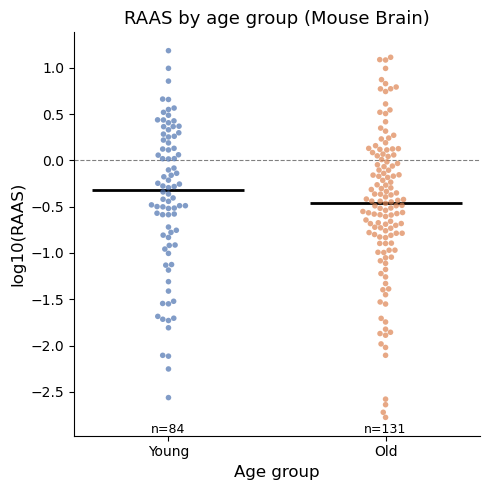

In [22]:
import seaborn as sns

# Mean log10 RAAS per SAAP per channel, then average within age group
raas_df['log10_RAAS'] = np.log10(raas_df['RAAS'])

mean_per_saap_age = (raas_df.groupby(['SAAP','age'])['log10_RAAS']
                              .mean().reset_index())

age_order = ['Young', 'Old']
age_colors = {'Young': '#4C72B0', 'Old': '#DD8452'}

fig, ax = plt.subplots(figsize=(5, 5))
sns.swarmplot(data=mean_per_saap_age, x='age', y='log10_RAAS',
              order=age_order, palette=age_colors, size=4, alpha=0.7, ax=ax)

for age in age_order:
    med = mean_per_saap_age.loc[mean_per_saap_age['age'] == age, 'log10_RAAS'].median()
    xi = age_order.index(age)
    ax.hlines(med, xi - 0.35, xi + 0.35, colors='black', linewidths=2)

ax.set_xlabel('Age group', fontsize=12)
ax.set_ylabel('log10(RAAS)', fontsize=12)
ax.set_title('RAAS by age group (Mouse Brain)', fontsize=13)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
n_young = mean_per_saap_age[mean_per_saap_age['age']=='Young']['SAAP'].nunique()
n_old   = mean_per_saap_age[mean_per_saap_age['age']=='Old']['SAAP'].nunique()
ax.text(0, ax.get_ylim()[0], f'n={n_young}', ha='center', va='bottom', fontsize=9)
ax.text(1, ax.get_ylim()[0], f'n={n_old}',   ha='center', va='bottom', fontsize=9)
sns.despine()
plt.tight_layout()
# plt.savefig('mouse_brain_RAAS_by_age.pdf', bbox_inches='tight')
plt.show()


/var/folders/7n/xnj310j510vfnmdrs9612db40000gn/T/ipykernel_82783/134488650.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mean_norm_per_saap_age, x='age', y='log10_RAAS_norm',


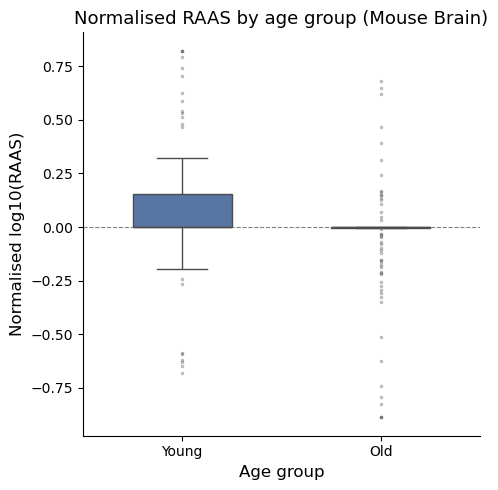

In [23]:
# Normalised RAAS: subtract per-SAAP mean across channels
saap_mean_all = raas_df.groupby('SAAP')['log10_RAAS'].mean().rename('saap_mean')
raas_norm = raas_df.merge(saap_mean_all, on='SAAP')
raas_norm['log10_RAAS_norm'] = raas_norm['log10_RAAS'] - raas_norm['saap_mean']

mean_norm_per_saap_age = (raas_norm.groupby(['SAAP','age'])['log10_RAAS_norm']
                                    .mean().reset_index())

# Clip to 1st-99th percentile
lo, hi = np.percentile(mean_norm_per_saap_age['log10_RAAS_norm'].dropna(), [1, 99])
mean_norm_per_saap_age['log10_RAAS_norm'] = mean_norm_per_saap_age['log10_RAAS_norm'].clip(lo, hi)

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=mean_norm_per_saap_age, x='age', y='log10_RAAS_norm',
            order=age_order, palette=age_colors, width=0.5,
            flierprops=dict(marker='.', markersize=3, alpha=0.4), ax=ax)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Age group', fontsize=12)
ax.set_ylabel('Normalised log10(RAAS)', fontsize=12)
ax.set_title('Normalised RAAS by age group (Mouse Brain)', fontsize=13)
sns.despine()
plt.tight_layout()
# plt.savefig('mouse_brain_RAAS_norm_by_age.pdf', bbox_inches='tight')
plt.show()


SAAPs in both Young and Old (intersection): 50
SAAPs tested (>=2 replicates per group): 7


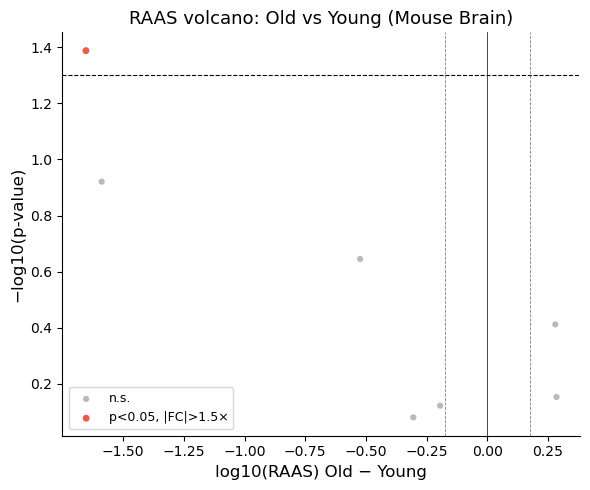

Significant: 0 higher in Old, 1 higher in Young


In [24]:
from scipy import stats

raas_df['log10_RAAS'] = np.log10(raas_df['RAAS'])

young_channels = [ch for ch, age in channel_age.items() if age == 'Young']
old_channels   = [ch for ch, age in channel_age.items() if age == 'Old']

# Pivot: rows = SAAP, columns = channel
raas_pivot = raas_df.pivot_table(index='SAAP', columns='channel',
                                  values='log10_RAAS', aggfunc='mean')

y_cols = [c for c in young_channels if c in raas_pivot.columns]
o_cols = [c for c in old_channels   if c in raas_pivot.columns]

# Intersection: SAAPs with at least 1 value in each group
mask = raas_pivot[y_cols].notna().any(axis=1) & \
       raas_pivot[o_cols].notna().any(axis=1)
raas_pivot = raas_pivot[mask]
print(f'SAAPs in both Young and Old (intersection): {len(raas_pivot)}')

# Welch t-test per SAAP, using only non-NaN channels per row
results = []
for saap, row in raas_pivot.iterrows():
    y_vals = row[y_cols].dropna().values.astype(float)
    o_vals = row[o_cols].dropna().values.astype(float)
    fc = o_vals.mean() - y_vals.mean()
    if len(y_vals) >= 2 and len(o_vals) >= 2:
        t, p = stats.ttest_ind(o_vals, y_vals, equal_var=False)
    else:
        p = np.nan
    results.append({'SAAP': saap, 'log10_FC': fc, 'pval': p})

volcano = pd.DataFrame(results).dropna(subset=['pval'])
volcano['neg_log10_p'] = -np.log10(volcano['pval'].clip(lower=1e-300))
print(f'SAAPs tested (>=2 replicates per group): {len(volcano)}')

# ── Plot ──────────────────────────────────────────────────────────────────────
sig_thresh = 0.05
fc_thresh  = np.log10(1.5)

volcano['sig'] = (volcano['pval'] < sig_thresh) & (volcano['log10_FC'].abs() > fc_thresh)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(volcano.loc[~volcano['sig'], 'log10_FC'],
           volcano.loc[~volcano['sig'], 'neg_log10_p'],
           c='#8C8C8C', s=20, alpha=0.6, edgecolors='none', label='n.s.')
ax.scatter(volcano.loc[volcano['sig'], 'log10_FC'],
           volcano.loc[volcano['sig'], 'neg_log10_p'],
           c='#E64B35', s=25, alpha=0.9, edgecolors='none',
           label=f'p<{sig_thresh}, |FC|>1.5×')

ax.axhline(-np.log10(sig_thresh), color='black', linestyle='--', linewidth=0.8)
ax.axvline( fc_thresh, color='grey', linestyle='--', linewidth=0.6)
ax.axvline(-fc_thresh, color='grey', linestyle='--', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_xlabel('log10(RAAS) Old − Young', fontsize=12)
ax.set_ylabel('−log10(p-value)', fontsize=12)
ax.set_title('RAAS volcano: Old vs Young (Mouse Brain)', fontsize=13)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
# plt.savefig('mouse_brain_volcano_old_vs_young.pdf', bbox_inches='tight')
plt.show()

n_up   = ((volcano['sig']) & (volcano['log10_FC'] > 0)).sum()
n_down = ((volcano['sig']) & (volcano['log10_FC'] < 0)).sum()
print(f'Significant: {n_up} higher in Old, {n_down} higher in Young')